# (c) Wine Quality Prediction using Ordinal Regression

The objective of this experiment is to predict wine quality using its physicochemical properties. Since the quality rating is ordered, I use ordinal logistic regression and compare it with linear regression. The dataset is divided into 80% training data and 20% testing data.

## Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mord import LogisticAT

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the dataset

In [3]:
red = pd.read_csv("data/wine/winequality-red.csv", sep=";")
white = pd.read_csv("data/wine/winequality-white.csv", sep=";")

print("Red wine:", red.shape)
print("White wine:", white.shape)

Red wine: (1599, 12)
White wine: (4898, 12)


In [7]:
wine = pd.concat([red, white], ignore_index=True)

print("Shape of dataset:", wine.shape)
print("\nColumns:")
print(wine.columns.tolist())

print("\nMissing values:")
print(wine.isnull().sum())

print("\nQuality distribution:")
print(wine["quality"].value_counts().sort_index())


Shape of dataset: (6497, 12)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


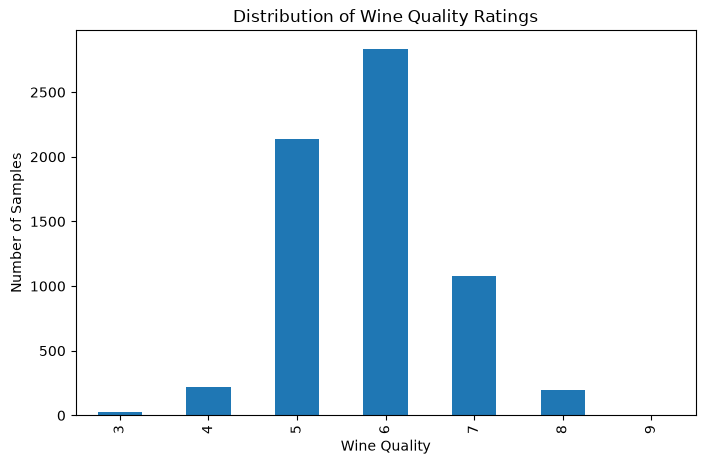

In [10]:
plt.figure(figsize=(8, 5))
wine["quality"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Samples")
plt.title("Distribution of Wine Quality Ratings")
plt.show()

The dataset does not contain any missing values. The quality ratings range from 3 to 9, with most observations having ratings of 5 or 6.

## Selecting Features and Target

The 11 physicochemical measurements are used as input features and `quality` is used as the target variable.

In [11]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

X = wine[features]
y = wine["quality"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6497, 11)
y shape: (6497,)


## Train-Test Split

I use 80% of the data for training and 20% for testing. Stratified splitting is used to maintain a similar distribution of quality ratings in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11009, stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5197
Testing samples: 1300


## Evaluation Metric
I use Mean Absolute Error (MAE) as the main evaluation metric because the target is an ordered rating. MAE measures the average difference between the actual and predicted quality ratings. RMSE and R² are also reported for comparison.

## Feature Standardization
The features are standardized before training because they have different ranges. The scaler is included in the model pipeline to avoid data leakage during cross-validation.

## Ordinal Logistic Regression
I use `LogisticAT` from the `mord` package for ordinal regression. The regularization parameter `alpha` is selected using 10-fold cross-validation.

In [13]:
ordinal_pipeline = Pipeline([("scaler", StandardScaler()), ("model", LogisticAT(max_iter=10000))])
param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=11009)
ordinal_grid = GridSearchCV(estimator=ordinal_pipeline, param_grid=param_grid, 
                            scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
ordinal_grid.fit(X_train, y_train)

print("Best alpha:", ordinal_grid.best_params_["model__alpha"])
print("Best 10-fold CV MAE:", -ordinal_grid.best_score_)

d:\PhD\Coursework\CS5590_FoML\Assignments\Assignment1\foml1\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


Best alpha: 0.001
Best 10-fold CV MAE: 0.5254994812509263


The best cross-validation result was obtained with `alpha = 0.001`, `0.01`, or `0.1`, all giving the same mean CV MAE of approximately 0.5255. I use the value selected by `GridSearchCV`, which is `0.001`.

In [15]:
best_ordinal_model = ordinal_grid.best_estimator_
y_pred_ordinal = best_ordinal_model.predict(X_test)
ordinal_mae = mean_absolute_error(y_test, y_pred_ordinal)
ordinal_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ordinal))
ordinal_r2 = r2_score(y_test, y_pred_ordinal)

print("Ordinal Regression Results")
print("--------------------------")
print("MAE :", ordinal_mae)
print("RMSE:", ordinal_rmse)
print("R^2  :", ordinal_r2)

Ordinal Regression Results
--------------------------
MAE : 0.5069230769230769
RMSE: 0.7908126297579063
R^2  : 0.18087229466586574


## Ordinal Regression Predictions

The ordinal regression model predicts discrete quality ratings. I compare the predicted ratings with the actual ratings to examine the model's performance.

In [ ]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_ordinal.astype(int)})
comparison.head()

,Actual,Predicted
0,6,5
1,5,5
2,7,6
3,6,6
4,6,6
5,7,6
6,4,5
7,5,5
8,5,5
9,6,6


In [17]:
ordinal_confusion = pd.crosstab(comparison["Actual"], comparison["Predicted"], 
                                rownames=["Actual"], colnames=["Predicted"])
ordinal_confusion

Predicted,5,6,7
Actual,,,
3,3,2,1
4,31,11,1
5,228,197,3
6,93,438,36
7,16,154,46
8,0,28,11
9,0,0,1


## Linear Regression

As a baseline, I use linear regression with the same training and testing data. Unlike ordinal regression, linear regression treats quality as a continuous numerical variable.

In [ ]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R^2  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 0.5624413014208488
RMSE: 0.732418249746566
R²  : 0.29737639462170384


## Model Comparison

The ordinal regression model achieves a lower MAE than linear regression, while linear regression achieves lower RMSE and higher R². Since MAE is the main metric for this ordinal prediction problem, the ordinal regression model performs better according to the selected metric.

In [ ]:
results = pd.DataFrame({
    "Model": ["Ordinal Logistic Regression", "Linear Regression"],
    "MAE": [ordinal_mae, linear_mae],
    "RMSE": [ordinal_rmse, linear_rmse],
})

results

,Model,MAE,RMSE,R2
0,Ordinal Logistic Regression,0.506923,0.790813,0.180872
1,Linear Regression,0.562441,0.732418,0.297376


For MAE and RMSE, a lower value is better, while for R2 a higher value is better. I mainly focus on MAE because it is easier to interpret for an ordinal rating. An MAE of 0.60, for example, means that the predictions are on average about 0.60 quality points away from the actual ratings.

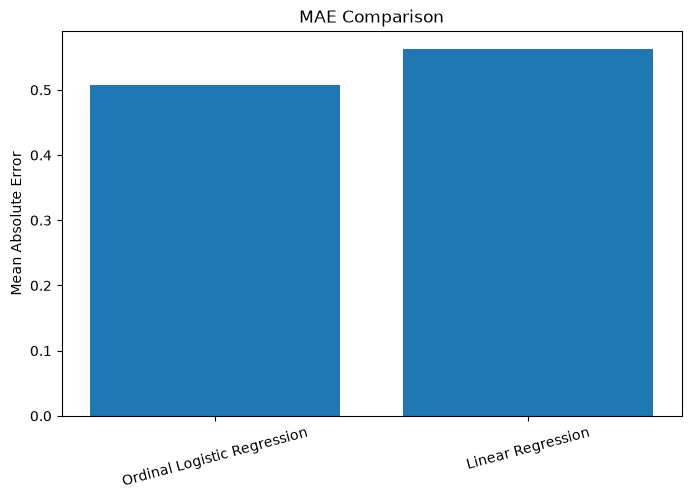

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MAE"])
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison")
plt.xticks(rotation=15)
plt.show()

## Actual vs Predicted Quality

The plot shows the relationship between the actual quality ratings and the ratings predicted by the ordinal regression model.

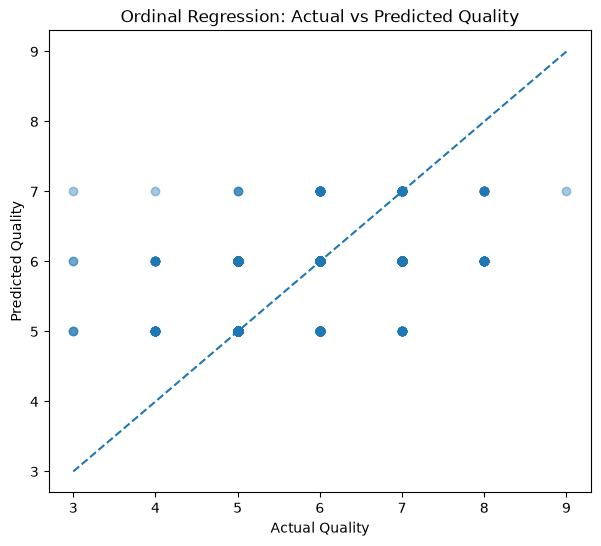

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ordinal, alpha=0.4)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Ordinal Regression: Actual vs Predicted Quality")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

## Prediction Errors

The distribution of prediction errors shows how far the ordinal regression predictions are from the actual quality ratings.

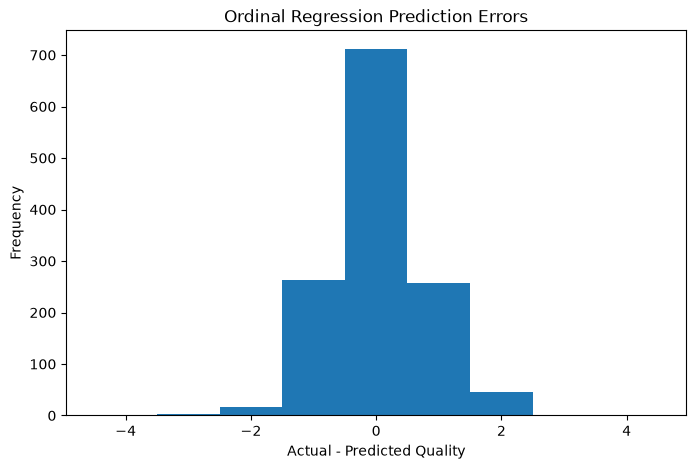

In [22]:
ordinal_errors = y_test.values - y_pred_ordinal.astype(int)

plt.figure(figsize=(8, 5))
plt.hist(ordinal_errors, bins=np.arange(-4.5, 5.5, 1))
plt.xlabel("Actual - Predicted Quality")
plt.ylabel("Frequency")
plt.title("Ordinal Regression Prediction Errors")
plt.show()

## 12. Final Results
The final test-set results are compared below. The ordinal regression model obtains an MAE of 0.5069, compared with 0.5624 for linear regression. This means that the ordinal model makes smaller errors on average.

In [ ]:
cv_results = pd.DataFrame(ordinal_grid.cv_results_)
cv_results[["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

,param_model__alpha,mean_test_score,std_test_score,rank_test_score
0,0.001,-0.525499,0.020788,1
1,0.010,-0.525499,0.020788,1
2,0.100,-0.525499,0.020788,1
3,1.000,-0.525692,0.020702,4
4,10.000,-0.526269,0.021507,5
5,100.000,-0.528383,0.017412,6


In [ ]:
cv_summary = cv_results[["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]].copy()
cv_summary["mean_CV_MAE"] = -cv_summary["mean_test_score"]
cv_summary["std_CV_MAE"] = cv_summary["std_test_score"]
cv_summary = cv_summary[["param_model__alpha", "mean_CV_MAE", "std_CV_MAE", "rank_test_score"]].sort_values("mean_CV_MAE")
cv_summary

,param_model__alpha,mean_CV_MAE,std_CV_MAE,rank_test_score
0,0.001,0.525499,0.020788,1
1,0.010,0.525499,0.020788,1
2,0.100,0.525499,0.020788,1
3,1.000,0.525692,0.020702,4
4,10.000,0.526269,0.021507,5
5,100.000,0.528383,0.017412,6


In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Ordinal Logistic Regression", "Linear Regression"],
    "MAE": [ordinal_mae, linear_mae],
    "RMSE": [ordinal_rmse, linear_rmse],
    "R2": [ordinal_r2, linear_r2]
})
final_comparison

,Model,MAE,RMSE,R2
0,Ordinal Logistic Regression,0.506923,0.790813,0.180872
1,Linear Regression,0.562441,0.732418,0.297376


## Conclusion
The ordinal logistic regression model achieved an MAE of 0.5069 on the test set, while linear regression achieved an MAE of 0.5624. Therefore, ordinal regression performed better according to the main evaluation metric. However, linear regression obtained a lower RMSE (0.7324 vs. 0.7908) and a higher R² (0.2974 vs. 0.1809). Overall, the results show that explicitly considering the ordered nature of the wine quality ratings improves MAE, although linear regression explains more of the numerical variation in the target.